***Loading Required Packages***

In [1]:
#loading packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import networkx as nx
import seaborn as sns
from geopy.distance import geodesic
from scipy.stats import pearsonr
from pathlib import Path
import sys

# Locate the project root regardless of where the notebook is executed from
cwd = Path.cwd()

if (cwd / "src").exists() and (cwd / "external").exists():
    project_root = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "external").exists():
    project_root = cwd.parent
else:
    raise RuntimeError("Could not locate the project root.")
figures_dir = project_root / "notebooks" / "output" / "figures"

sys.path.append(str(project_root / "external"))
sys.path.append(str(project_root / "src"))

from BaseEdgeGNAR_edge import GNAREdgeLearner
from BaseEdgeGNAR_edge_global import GNAREdgeGlobalLearner
from edge_graph import ArrayEdgeGraph
from RollingEdgePredict import RollingEdgePredict
from real_data_pipeline import edge_weights_distribution

#loading external data
interactions_path = project_root / "data" / "baboons_proximity_data.txt"
max_temp_path = project_root / "data" / "trets.csv"
baboon_data_path = project_root / "data" / "baboon_data.csv"



***Visualising distribution of daily interactions across baboon pairs***

Total recorded interactions: 63095


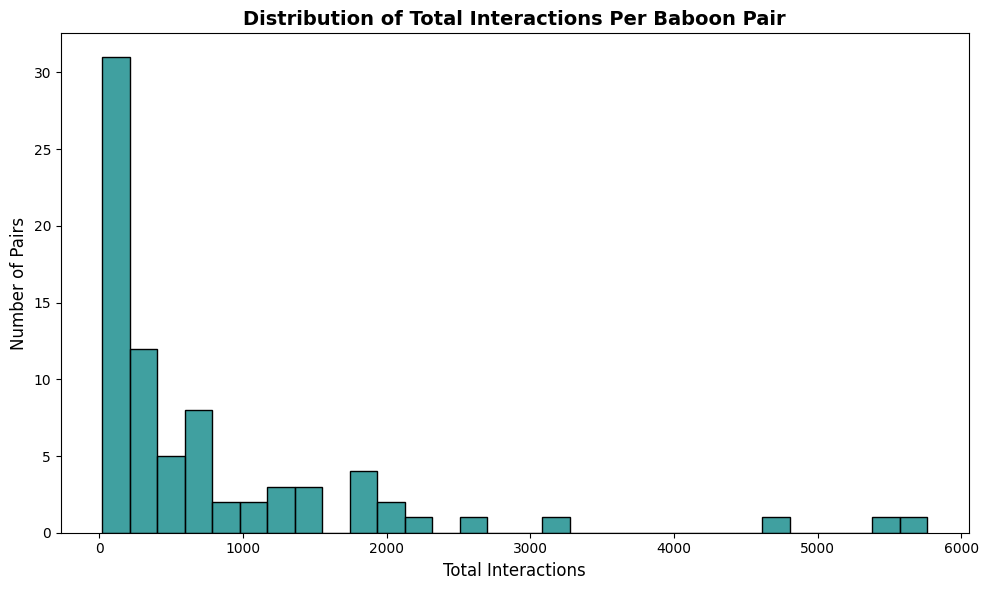

             pair  total interactions
5   ANGELE-FELIPE                5764
73      KALI-PIPO                5478
42     EWINE-FANA                4783
Mean Interactions: 808.91
Median Interactions: 328.50


In [2]:
#loading data
df = pd.read_csv(interactions_path, sep = "\t")
df["DateTime"] = pd.to_datetime(df["DateTime"], format = "%d/%m/%Y %H:%M")

#total number of recorded interactions
print("Total recorded interactions:", len(df))

#creating baboon pairs
df[["baboon1", "baboon2"]] = pd.DataFrame(
    df.apply(lambda row: sorted([row["i"], row["j"]]), axis = 1).tolist(),
    index = df.index
)

#aggregating interactions by day
df["day"] = df["DateTime"].dt.floor("1D")
df.drop(columns = ["i","j","t","DateTime"], inplace=True)
interaction_counts = (
    df.groupby(["day", "baboon1", "baboon2"]).size().reset_index(name = "interaction_count")
)
interaction_counts["pair"] = interaction_counts["baboon1"].astype(str) + "-" + interaction_counts["baboon2"].astype(str)
per_pair_total_interactions_df = (
    interaction_counts.groupby("pair")["interaction_count"]
    .sum()
    .reset_index(name="total interactions")
)

#histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=per_pair_total_interactions_df, x="total interactions", bins=30, color = "teal")
plt.title("Distribution of Total Interactions Per Baboon Pair", fontsize=14, fontweight="bold")
plt.xlabel("Total Interactions", fontsize=12)
plt.ylabel("Number of Pairs", fontsize=12)
plt.tight_layout()
plt.savefig(figures_dir / "interaction_histogram.pdf", dpi = 300, bbox_inches = "tight")
plt.show()

#strongest baboon pairs
print(per_pair_total_interactions_df.sort_values("total interactions", ascending=False).head(3))

#mean, standard deviation and coefficient of variation
mean_total_interactions = per_pair_total_interactions_df["total interactions"].mean()
median_total_interactions = per_pair_total_interactions_df["total interactions"].median()

print(f"Mean Interactions: {mean_total_interactions:.2f}")
print(f"Median Interactions: {median_total_interactions:.2f}")


Adding labels specifically for the top 3 pairs

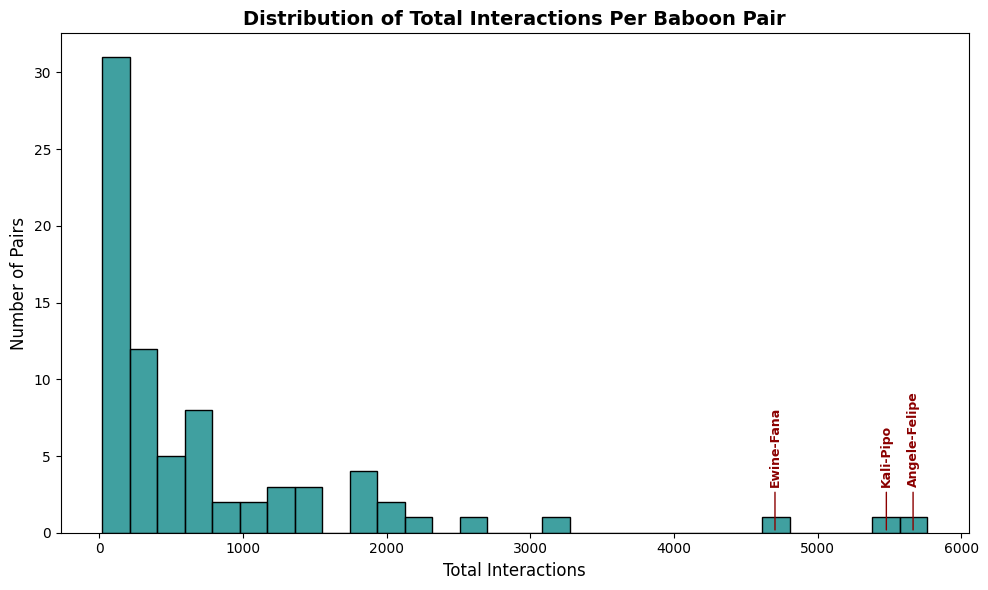

In [12]:
#top 3 pairs to label (numbers do not exactly equal interaction counts, so that labels are in the middle of the bars)
top_pairs = {
    "Angele-Felipe": 5664,
    "Kali-Pipo": 5478,
    "Ewine-Fana": 4703
}

#histogram
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=per_pair_total_interactions_df, x="total interactions", bins=30, color="teal")

#label the top 3 bars
for pair_name, value in top_pairs.items():
    plt.annotate(
        pair_name,
        xy=(value, 0),              
        xytext=(value, 3),         
        rotation=90,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="darkred",
        arrowprops=dict(arrowstyle="-", color="darkred", lw=1)
    )

plt.title("Distribution of Total Interactions Per Baboon Pair", fontsize=14, fontweight="bold")
plt.xlabel("Total Interactions", fontsize=12)
plt.ylabel("Number of Pairs", fontsize=12)
plt.tight_layout()
plt.savefig(figures_dir / "interaction_histogram_labelled.pdf", dpi=300, bbox_inches="tight")
plt.show()

Variation in Interactions by Age/Sex Composition

In [3]:
#age and gender data
baboon_data = pd.read_csv(
    baboon_data_path,
    parse_dates=["dob"],
    dayfirst= True
)
baboon_df = pd.DataFrame(baboon_data)

#calculating ages
study_start = pd.to_datetime("2019-06-13")
baboon_df['dob'] = pd.to_datetime(baboon_df['dob'], format='%d-%m-%Y')
baboon_df['age'] = (study_start - baboon_df['dob']).dt.days / 365.25
baboon_df

#number of males and females
print("Number of females:", (baboon_df["sex"] == "F").sum())
print("Number of males:", (baboon_df["sex"] == "M").sum())

#age composition
print("Minimum Age:", (baboon_df["age"]).min())
print("Maximum Age:", (baboon_df["age"]).max())
print("Mean Age:", (baboon_df["age"]).mean())

#temporary dataframe used to merge an age, sex and interactions dataframe
temp_df = per_pair_total_interactions_df.copy()
temp_df[["b1", "b2"]] = temp_df["pair"].str.split("-", expand=True)

temp_df = temp_df.merge(
    baboon_df[["name", "sex", "age"]], left_on="b1", right_on="name"
).rename(columns={"sex": "sex1", "age": "age1"}).drop(columns=["name"])

temp_df = temp_df.merge(
    baboon_df[["name", "sex", "age"]], left_on="b2", right_on="name"
).rename(columns={"sex": "sex2", "age": "age2"}).drop(columns=["name"])

temp_df["same_sex"] = (temp_df["sex1"] == temp_df["sex2"]).astype(int)
temp_df["mean_age"] = (temp_df["age1"] + temp_df["age2"]) / 2
temp_df["age_diff"] = (temp_df["age1"] - temp_df["age2"]).abs()

age_sex_interactions_df = temp_df[["pair", "total interactions", "same_sex", "mean_age", "age_diff"]]

#calculating percentage difference in interactions between same sex and mixed sex pairs
same_vs_mixed = age_sex_interactions_df.groupby("same_sex")["total interactions"].mean()
same_vs_mixed_pct_diff = (same_vs_mixed[0] - same_vs_mixed[1])/same_vs_mixed[1]
print("Percentage increase in interactions between same-sex vs mixed-sex pairs:", same_vs_mixed_pct_diff)


print("Correlation between age difference and total interactions", age_sex_interactions_df["age_diff"].corr(age_sex_interactions_df["total interactions"]))
print("Correlation between mean age and total interactions", age_sex_interactions_df["mean_age"].corr(age_sex_interactions_df["total interactions"]))


Number of females: 9
Number of males: 4
Minimum Age: 6.907597535934292
Maximum Age: 23.76728268309377
Mean Age: 14.162691517927659
Percentage increase in interactions between same-sex vs mixed-sex pairs: 0.07893532641854793
Correlation between age difference and total interactions -0.2382228364604959
Correlation between mean age and total interactions -0.18899047739648456


Temporal variation in interaction counts, aggregated over baboon pairs

In [4]:
#loading in temperature data
weather_data = pd.read_csv(
    max_temp_path,
    sep = ";",
    decimal= ","
)
weather_data = weather_data[["DATE","TX"]]
weather_data = weather_data.rename(columns = {"TX": "temp_max"})
weather_data["DATE"] = pd.to_datetime(
    weather_data["DATE"],
    format= "%Y%m%d"
)

#creating a joint dataframe of interaction counts and 
#maximum temperature
daily_interactions = (
    interaction_counts.groupby("day")["interaction_count"]
    .sum()
    .reset_index(name="total_interactions")
)

daily_weather_interactions_df = daily_interactions.merge(
    weather_data, 
    left_on="day", 
    right_on="DATE", 
    how="inner"
).drop(columns=["DATE"])

daily_weather_interactions_df.rename(columns={"day": "date"}, inplace=True)
daily_weather_interactions_df = daily_weather_interactions_df[["date", "total_interactions", "temp_max"]]
daily_weather_interactions_df = daily_weather_interactions_df.sort_values("date")

#computing mean, std dev and coefficient of variation of daily interactions
mean_daily_interactions = daily_weather_interactions_df["total_interactions"].mean()
std_daily_interactions = daily_weather_interactions_df["total_interactions"].std()
cv_daily_interactions = mean_daily_interactions / std_daily_interactions

#daily interactions - summary stats
print("Mean Daily Interactions:", mean_daily_interactions)
print("Daily Interactions Coefficient of Variation:", cv_daily_interactions)
print(daily_weather_interactions_df["total_interactions"].describe())



Mean Daily Interactions: 2253.3928571428573
Daily Interactions Coefficient of Variation: 4.580065844274668
count      28.000000
mean     2253.392857
std       492.000101
min      1457.000000
25%      1915.250000
50%      2253.000000
75%      2493.500000
max      3577.000000
Name: total_interactions, dtype: float64


Investigating the relationship between maximum temperature and interaction counts

Rousset to Trets distance: 6.21 km


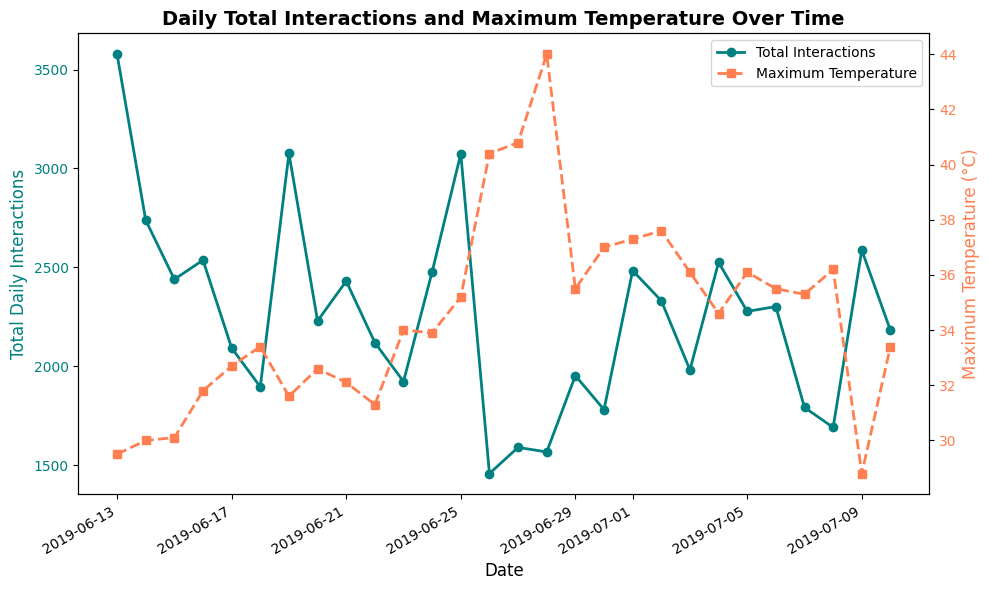

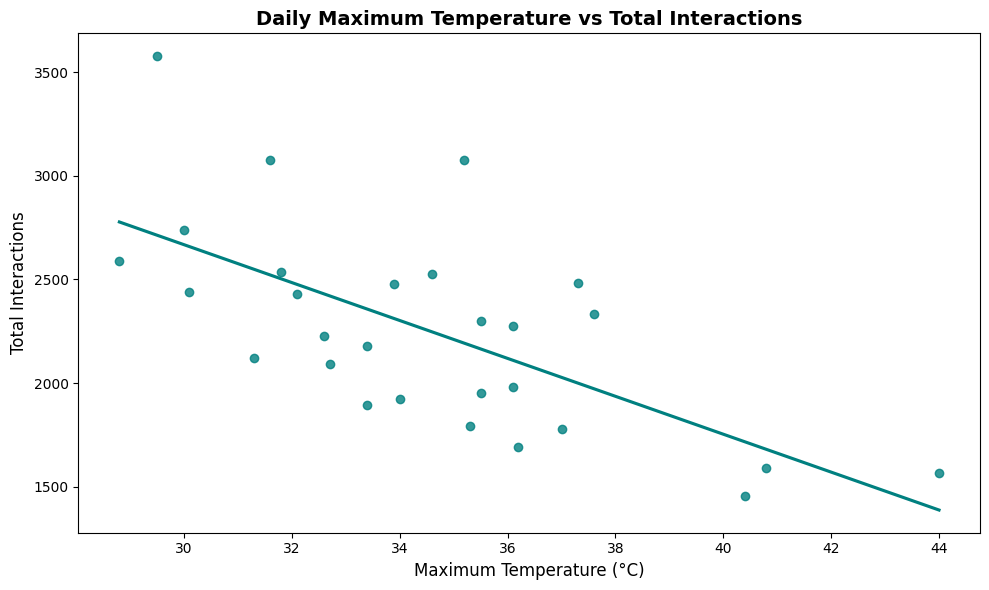

Correlation between max temp and daily interactions: -0.6574


In [14]:
#trets to rousset distance
rousset_coords = (43.478333, 5.636667)
trets_coords = (43.445333 , 5.698667)
print(f"Rousset to Trets distance: {geodesic(rousset_coords, trets_coords).km:.2f} km")


#plotting daily interactions and temperature time series
fig, ax1 = plt.subplots(figsize=(10, 6))


ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Total Daily Interactions", color="teal", fontsize=12)
ax1.plot(
    daily_weather_interactions_df["date"], 
    daily_weather_interactions_df["total_interactions"], 
    color="teal", 
    marker="o", 
    linewidth=2, 
    label="Total Interactions"
)
ax1.tick_params(axis="y", labelcolor="teal")


ax2 = ax1.twinx()
ax2.set_ylabel("Maximum Temperature (°C)", color="coral", fontsize=12)
ax2.plot(
    daily_weather_interactions_df["date"], 
    daily_weather_interactions_df["temp_max"], 
    color="coral", 
    marker="s", 
    linewidth=2, 
    linestyle="--", 
    label="Maximum Temperature"
)
ax2.tick_params(axis="y", labelcolor="coral")


plt.title("Daily Total Interactions and Maximum Temperature Over Time", fontsize=14, fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(figures_dir / "interactions_temp_over_time.pdf", dpi=300, bbox_inches="tight")
plt.show()


#plotting maximum temperature vs total interactions scatterplot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=daily_weather_interactions_df,
    x="temp_max",
    y="total_interactions",
    color="teal",
    ci = None
)

plt.title("Daily Maximum Temperature vs Total Interactions", fontsize=14, fontweight="bold")
plt.xlabel("Maximum Temperature (°C)", fontsize=12)
plt.ylabel("Total Interactions", fontsize=12)

plt.tight_layout()
plt.savefig(figures_dir / "interactions_vs_max_temp.pdf", dpi=300, bbox_inches="tight")
plt.show()


#correlation calculation between max temp and interactions
corr = daily_weather_interactions_df["temp_max"].corr(daily_weather_interactions_df["total_interactions"])
print(f"Correlation between max temp and daily interactions: {corr:.4f}")

Investigating variation across pairs in relationship between interactions and maximum temperature 

[GNAREdgeGlobalLearner] epoch=001 loss=1466.67454034 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1466.6745403398702 train_set_time=nans fit_time=0.019s stop=ols_closed_form
[GNAREdgeGlobalLearner] epoch=001 loss=1451.67779800 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1451.6777980036825 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalLearner] epoch=001 loss=1414.20512212 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1414.205122119318 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalLearner] epoch=001 loss=1379.42063980 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1379.4206398004792 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalLearner] e

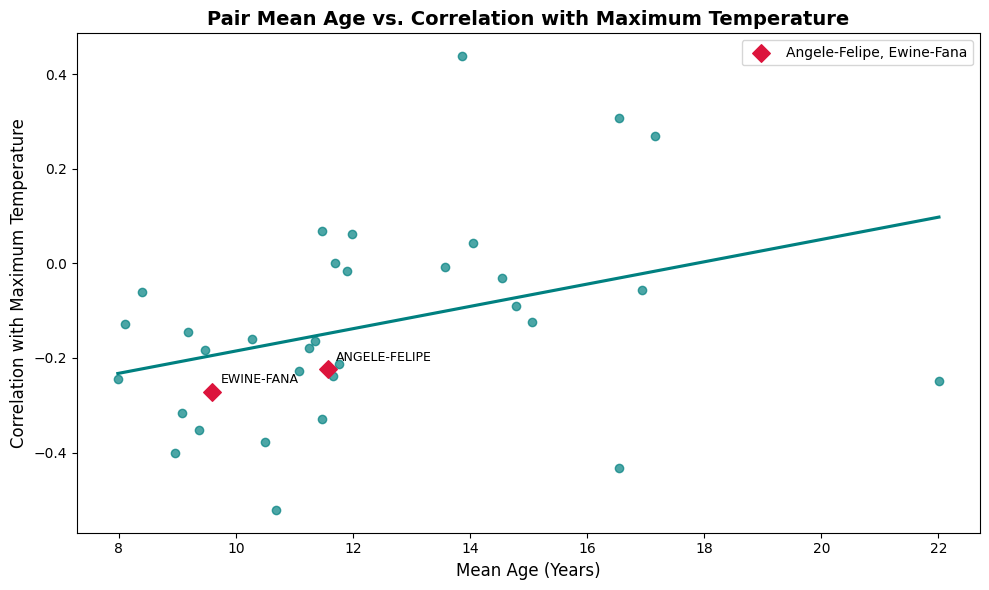

In [13]:
#data frame of interaction counts for each pair in the persistent edge list
out = edge_weights_distribution(
    path=interactions_path,
    weight_mode="count",
    transform="none"
)
edge_df = out["edge_weight_raw_df"]

#computing correlation with maximum temperature, for each edge
per_edge_corr = []
for edge in edge_df.columns:
    r, p = pearsonr(edge_df[edge], daily_weather_interactions_df["temp_max"])
    
    per_edge_corr.append({
        "edge": edge,
        "mean_edge_weight": edge_df[edge].mean(),
        "max_temp_corr": r,
        "p_value": p
    })

edge_corr_df = pd.DataFrame(per_edge_corr)

print(edge_corr_df["max_temp_corr"].describe())
print("Proportion of edges with negative correlation:", (edge_corr_df["max_temp_corr"] < 0).mean())

edge_corr_df = edge_corr_df.merge(
    temp_df[["pair", "mean_age"]], 
    left_on="edge", 
    right_on="pair", 
    how="left"
).drop(columns=["pair"])

#pairs to highlight
highlight_pairs = ["ANGELE-FELIPE", "EWINE-FANA"]
edge_corr_df["highlight"] = edge_corr_df["edge"].isin(highlight_pairs)

fig = plt.figure(figsize=(10, 6))

#base scatter + regression line
sns.regplot(
    data=edge_corr_df,
    x="mean_age",
    y="max_temp_corr",
    color="teal",
    scatter_kws={"alpha": 0.7},
    ci = None
)

#highlighted pairs, plotted separately in a different colour/marker
highlight_df = edge_corr_df[edge_corr_df["highlight"]]
plt.scatter(
    highlight_df["mean_age"],
    highlight_df["max_temp_corr"],
    color="crimson",
    marker="D",
    s=80,
    zorder=5,
    label="Angele-Felipe, Ewine-Fana",
)

for _, row in highlight_df.iterrows():
    plt.annotate(
        row["edge"],
        (row["mean_age"], row["max_temp_corr"]),
        textcoords="offset points", xytext=(6, 6), fontsize=9,
    )

plt.title("Pair Mean Age vs. Correlation with Maximum Temperature", fontsize=14, fontweight="bold")
plt.xlabel("Mean Age (Years)", fontsize=12)
plt.ylabel("Correlation with Maximum Temperature", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "mean_age_vs_temp_corr.pdf", dpi=300, bbox_inches="tight")
plt.show()